In [ ]:
# import kagglehub

# # Download latest version
# path = kagglehub.dataset_download("andrewmvd/covid19-ct-scans")

# print("Path to dataset files:", path)

import kagglehub

# Download latest version
path = kagglehub.dataset_download("luumsk/medical-segmentation-decathlon-lung")

print("Path to dataset files:", path)



100%|██████████| 8.90G/8.90G [07:29<00:00, 21.3MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/luumsk/medical-segmentation-decathlon-lung/versions/7


In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# x=[]
# y=[]
# z=[]
# for i in range(20):
#   p = '/root/.cache/kagglehub/datasets/andrewmvd/covid19-ct-scans/versions/4/ct_scans/'+os.listdir('/root/.cache/kagglehub/datasets/andrewmvd/covid19-ct-scans/versions/4/ct_scans')[i]
#   if 'coronacases' in p:
#     img = nib.load(p).get_fdata()
#     x.append(img.shape[0])
#     y.append(img.shape[1])
#     z.append(img.shape[2])

# print('Total Images: ',sum(z)+sum(x)+sum(y))

# **Setup the Environment**

In [ ]:
!pip install nilearn niwidgets numpy-stl -q
!pip install open3d k3d -q
!pip3 install ipympl -q
!pip install niwidgets --no-deps

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 3.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 121.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 67.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 84.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 78.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 112.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 260.7/260.7 kB 23.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 271.7/271.7 kB 23.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 74.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 447.7/447.7 MB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.1/23.1 MB 33.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 121.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━

**After succesful installation, restart and clear cell outputs.**
Comment the above lines, hit run all

# **Import all dependencies**

In [ ]:
import os, glob
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import load_model
from tensorflow import keras
import shutil, pathlib, fnmatch
import PIL
from niwidgets import NiftiWidget
import numpy as np
import open3d as o3d
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
from skimage import measure
from stl import mesh
from sklearn.metrics import confusion_matrix
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from scipy.ndimage import binary_closing, binary_dilation, binary_erosion, generate_binary_structure


# **Pre-processing**

In [ ]:
from warnings import filterwarnings

filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch import nn
import os
import gc
import random
from IPython.display import display
import ipywidgets as widgets
from ipywidgets import interact

from tqdm.auto import tqdm
import torch.nn.functional as F
from torchvision.transforms.v2 import GaussianNoise
# from torchmetrics import JaccardIndex, Precision, Recall, Specificity, F1Score, AUROC
import torch.optim as optim

from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr_skimage
from skimage.metrics import mean_squared_error as mse_skimage
from skimage.metrics import hausdorff_distance
from scipy.ndimage import distance_transform_edt
from tensorflow.keras.preprocessing.image import load_img
from keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import Dataset
from torch.utils.data import DataLoader


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:


def fuse_conv(conv, norm):
    fused_conv = torch.nn.Conv2d(conv.in_channels,
                                 conv.out_channels,
                                 kernel_size=conv.kernel_size,
                                 stride=conv.stride,
                                 padding=conv.padding,
                                 groups=conv.groups,
                                 bias=True).requires_grad_(False).to(conv.weight.device)

    w_conv = conv.weight.clone().view(conv.out_channels, -1)
    w_norm = torch.diag(norm.weight.div(torch.sqrt(norm.eps + norm.running_var)))
    fused_conv.weight.copy_(torch.mm(w_norm, w_conv).view(fused_conv.weight.size()))

    b_conv = torch.zeros(conv.weight.size(0), device=conv.weight.device) if conv.bias is None else conv.bias
    b_norm = norm.bias - norm.weight.mul(norm.running_mean).div(torch.sqrt(norm.running_var + norm.eps))
    fused_conv.bias.copy_(torch.mm(w_norm, b_conv.reshape(-1, 1)).reshape(-1) + b_norm)

    return fused_conv


class Conv(torch.nn.Module):
    def __init__(self, in_ch, out_ch, activation, k=1, s=1, p=0, g=1):
        super().__init__()
        self.conv = torch.nn.Conv2d(in_ch, out_ch, k, s, p, groups=g, bias=False)
        self.norm = torch.nn.BatchNorm2d(out_ch, eps=0.001, momentum=0.03)
        self.relu = activation

    def forward(self, x):
        return self.relu(self.norm(self.conv(x)))

    def fuse_forward(self, x):
        return self.relu(self.conv(x))


class Residual(torch.nn.Module):
    def __init__(self, ch, e=0.5):
        super().__init__()
        self.conv1 = Conv(ch, int(ch * e), torch.nn.SiLU(), k=3, p=1)
        self.conv2 = Conv(int(ch * e), ch, torch.nn.SiLU(), k=3, p=1)

    def forward(self, x):
        return x + self.conv2(self.conv1(x))


class C3K(torch.nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv1 = Conv(in_ch, out_ch // 2, torch.nn.SiLU())
        self.conv2 = Conv(in_ch, out_ch // 2, torch.nn.SiLU())
        self.conv3 = Conv(2 * (out_ch // 2), out_ch, torch.nn.SiLU())
        self.res_m = torch.nn.Sequential(Residual(out_ch // 2, e=1.0),
                                         Residual(out_ch // 2, e=1.0))

    def forward(self, x):
        y = self.res_m(self.conv1(x))
        return self.conv3(torch.cat((y, self.conv2(x)), dim=1))


class C3K2(torch.nn.Module):
    def __init__(self, in_ch, out_ch, n, csp, r):
        super().__init__()
        self.conv1 = Conv(in_ch, 2 * (out_ch // r), torch.nn.SiLU())
        self.conv2 = Conv((2 + n) * (out_ch // r), out_ch, torch.nn.SiLU())

        if not csp:
            self.res_m = torch.nn.ModuleList(Residual(out_ch // r) for _ in range(n))
        else:
            self.res_m = torch.nn.ModuleList(C3K(out_ch // r, out_ch // r) for _ in range(n))

    def forward(self, x):
        y = list(self.conv1(x).chunk(2, 1))
        y.extend(m(y[-1]) for m in self.res_m)
        return self.conv2(torch.cat(y, dim=1))


class SPP(torch.nn.Module):
    def __init__(self, in_ch, out_ch, k=5):
        super().__init__()
        self.conv1 = Conv(in_ch, in_ch // 2, torch.nn.SiLU())
        self.conv2 = Conv(in_ch * 2, out_ch, torch.nn.SiLU())
        self.res_m = torch.nn.MaxPool2d(k, stride=1, padding=k // 2)

    def forward(self, x):
        x = self.conv1(x)
        y1 = self.res_m(x)
        y2 = self.res_m(y1)
        return self.conv2(torch.cat(tensors=[x, y1, y2, self.res_m(y2)], dim=1))


class Attention(torch.nn.Module):

    def __init__(self, ch, num_head):
        super().__init__()
        self.num_head = num_head
        self.dim_head = ch // num_head
        self.dim_key = self.dim_head // 2
        self.scale = self.dim_key ** -0.5

        self.qkv = Conv(ch, ch + self.dim_key * num_head * 2, torch.nn.Identity())

        self.conv1 = Conv(ch, ch, torch.nn.Identity(), k=3, p=1, g=ch)
        self.conv2 = Conv(ch, ch, torch.nn.Identity())

    def forward(self, x):
        b, c, h, w = x.shape

        qkv = self.qkv(x)
        qkv = qkv.view(b, self.num_head, self.dim_key * 2 + self.dim_head, h * w)

        q, k, v = qkv.split([self.dim_key, self.dim_key, self.dim_head], dim=2)

        attn = (q.transpose(-2, -1) @ k) * self.scale
        attn = attn.softmax(dim=-1)

        x = (v @ attn.transpose(-2, -1)).view(b, c, h, w) + self.conv1(v.reshape(b, c, h, w))
        return self.conv2(x)


class PSABlock(torch.nn.Module):

    def __init__(self, ch, num_head):
        super().__init__()
        self.conv1 = Attention(ch, num_head)
        self.conv2 = torch.nn.Sequential(Conv(ch, ch * 2, torch.nn.SiLU()),
                                         Conv(ch * 2, ch, torch.nn.Identity()))

    def forward(self, x):
        x = x + self.conv1(x)
        return x + self.conv2(x)


class PSA(torch.nn.Module):
    def __init__(self, ch, n):
        super().__init__()
        self.conv1 = Conv(ch, 2 * (ch // 2), torch.nn.SiLU())
        self.conv2 = Conv(2 * (ch // 2), ch, torch.nn.SiLU())
        self.res_m = torch.nn.Sequential(*(PSABlock(ch // 2, ch // 128) for _ in range(n)))

    def forward(self, x):
        x, y = self.conv1(x).chunk(2, 1)
        return self.conv2(torch.cat(tensors=(x, self.res_m(y)), dim=1))


class DarkNet(torch.nn.Module):
    def __init__(self, width, depth, csp):
        super().__init__()
        self.p1 = []
        self.p2 = []
        self.p3 = []
        self.p4 = []
        self.p5 = []

        # p1/2
        self.p1.append(Conv(width[0], width[1], torch.nn.SiLU(), k=3, s=2, p=1))
        # p2/4
        self.p2.append(Conv(width[1], width[2], torch.nn.SiLU(), k=3, s=2, p=1))
        self.p2.append(C3K2(width[2], width[3], depth[0], csp[0], r=4))
        # p3/8
        self.p3.append(Conv(width[3], width[3], torch.nn.SiLU(), k=3, s=2, p=1))
        self.p3.append(C3K2(width[3], width[4], depth[1], csp[0], r=4))
        # p4/16
        self.p4.append(Conv(width[4], width[4], torch.nn.SiLU(), k=3, s=2, p=1))
        self.p4.append(C3K2(width[4], width[4], depth[2], csp[1], r=2))
        # p5/32
        self.p5.append(Conv(width[4], width[5], torch.nn.SiLU(), k=3, s=2, p=1))
        self.p5.append(C3K2(width[5], width[5], depth[3], csp[1], r=2))
        self.p5.append(SPP(width[5], width[5]))
        self.p5.append(PSA(width[5], depth[4]))

        self.p1 = torch.nn.Sequential(*self.p1)
        self.p2 = torch.nn.Sequential(*self.p2)
        self.p3 = torch.nn.Sequential(*self.p3)
        self.p4 = torch.nn.Sequential(*self.p4)
        self.p5 = torch.nn.Sequential(*self.p5)

    def forward(self, x):
        p1 = self.p1(x)
        p2 = self.p2(p1)
        p3 = self.p3(p2)
        p4 = self.p4(p3)
        p5 = self.p5(p4)
        return p1, p2, p3, p4, p5

class DarkFPN(torch.nn.Module):
    def __init__(self, width, depth, csp):
        super().__init__()
        self.up = torch.nn.Upsample(scale_factor=2)
        self.h1 = C3K2(width[4] + width[5], width[4], depth[5], csp[0], r=2)
        self.h2 = C3K2(width[4] + width[4], width[3], depth[5], csp[0], r=2)
        self.h3 = Conv(width[3], width[3], torch.nn.SiLU(), k=3, s=2, p=1)
        self.h4 = C3K2(width[3] + width[4], width[4], depth[5], csp[0], r=2)
        self.h5 = Conv(width[4], width[4], torch.nn.SiLU(), k=3, s=2, p=1)
        self.h6 = C3K2(width[4] + width[5], width[5], depth[5], csp[1], r=2)

    def forward(self, x):
        p1, p2, p3, p4, p5 = x
        p4 = self.h1(torch.cat([self.up(p5), p4], dim=1))
        p3 = self.h2(torch.cat([self.up(p4), p3], dim=1))
        p4 = self.h4(torch.cat([self.h3(p3), p4], dim=1))
        p5 = self.h6(torch.cat([self.h5(p4), p5], dim=1))
        return p1, p2, p3, p4, p5


class SegmentationHead(torch.nn.Module):
    def __init__(self, p5_channels, p4_channels, p3_channels, p2_channels, p1_channels, num_classes):
        super().__init__()
        self.up1 = torch.nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.conv1 = Conv(p5_channels + p4_channels, p5_channels, torch.nn.SiLU(), k=3, p=1)

        self.up2 = torch.nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.conv2 = Conv(p5_channels + p3_channels, p5_channels // 2, torch.nn.SiLU(), k=3, p=1)

        self.up3 = torch.nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.conv3 = Conv(p5_channels // 2 + p2_channels, p5_channels // 4, torch.nn.SiLU(), k=3, p=1)

        self.up4 = torch.nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.conv4 = Conv(p5_channels // 4 + p1_channels, p5_channels // 8, torch.nn.SiLU(), k=3, p=1)

        self.up5 = torch.nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.conv5 = Conv(p5_channels // 8, p5_channels // 8, torch.nn.SiLU(), k=3, p=1)

        self.final = torch.nn.Conv2d(p5_channels // 8, num_classes, kernel_size=1)

    def forward(self, p5, p4, p3, p2, p1):
        x = self.up1(p5)  # 16 → 32
        x = torch.cat([x, p4], dim=1)
        x = self.conv1(x)

        x = self.up2(x)  # 32 → 64
        x = torch.cat([x, p3], dim=1)
        x = self.conv2(x)

        x = self.up3(x)  # 64 → 128
        x = torch.cat([x, p2], dim=1)
        x = self.conv3(x)

        x = self.up4(x)  # 128 → 256
        x = torch.cat([x, p1], dim=1)
        x = self.conv4(x)

        x = self.up5(x)  # 256 → 512
        x = self.conv5(x)

        return self.final(x)

class DenoisingHead(torch.nn.Module):
    def __init__(self, p5_channels, p4_channels, p3_channels, p2_channels, p1_channels):
        super().__init__()
        self.up1 = torch.nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.conv1 = Conv(p5_channels + p4_channels, p5_channels, torch.nn.SiLU(), k=3, p=1)

        self.up2 = torch.nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.conv2 = Conv(p5_channels + p3_channels, p5_channels // 2, torch.nn.SiLU(), k=3, p=1)

        self.up3 = torch.nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.conv3 = Conv(p5_channels // 2 + p2_channels, p5_channels // 4, torch.nn.SiLU(), k=3, p=1)

        self.up4 = torch.nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.conv4 = Conv(p5_channels // 4 + p1_channels, p5_channels // 8, torch.nn.SiLU(), k=3, p=1)

        self.up5 = torch.nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.conv5 = Conv(p5_channels // 8, p5_channels // 8, torch.nn.SiLU(), k=3, p=1)

        self.final = torch.nn.Conv2d(p5_channels // 8, 1, kernel_size=1)

    def forward(self, p5, p4, p3, p2, p1):
        x = self.up1(p5)
        x = torch.cat([x, p4], dim=1)
        x = self.conv1(x)

        x = self.up2(x)
        x = torch.cat([x, p3], dim=1)
        x = self.conv2(x)

        x = self.up3(x)
        x = torch.cat([x, p2], dim=1)
        x = self.conv3(x)

        x = self.up4(x)
        x = torch.cat([x, p1], dim=1)
        x = self.conv4(x)

        x = self.up5(x)
        x = self.conv5(x)

        return torch.sigmoid(self.final(x))


class MT_UNet_YOLO_Large(torch.nn.Module):
    def __init__(self, width, depth, csp, num_classes):
        super().__init__()
        self.net = DarkNet(width, depth, csp)
        self.fpn = DarkFPN(width, depth, csp)

        # Dummy input to infer FPN output shapes
        img_dummy = torch.zeros(1, width[0], 512, 512)
        p1, p2, p3, p4, p5 = self.fpn(self.net(img_dummy))  # Get actual shapes

        # Task heads now use correct channel counts from FPN outputs
        self.seg_head = SegmentationHead(p5_channels=p5.shape[1], p4_channels=p4.shape[1],p3_channels=p3.shape[1],p2_channels=p2.shape[1],p1_channels=p1.shape[1], num_classes=num_classes)

    def forward(self, x):
        p1, p2, p3, p4, p5 = self.fpn(self.net(x))

        seg_out = self.seg_head(p5, p4, p3, p2, p1)

        return seg_out

    def fuse(self):
        for m in self.modules():
            if type(m) is Conv and hasattr(m, 'norm'):
                m.conv = fuse_conv(m.conv, m.norm)
                m.forward = m.fuse_forward
                delattr(m, 'norm')
        return self




In [ ]:
test_model = MT_UNet_YOLO_Large([1, 64, 128, 256, 512, 512], [1,1,1,1,1,1], [True, True], 1).to(device)
test_model.load_state_dict(torch.load('YOU-Net_best_val_loss.pt'))

<All keys matched successfully>

In [ ]:
import tensorflow as tf

def dice_coefficient(y_true, y_pred):
    """
    Calculates the Dice coefficient for segmentation masks.

    Args:
        y_true (tf.Tensor): True masks.
        y_pred (tf.Tensor): Predicted masks.

    Returns:
        tf.Tensor: Dice coefficient.
    """
    y_true_f = tf.cast(tf.keras.layers.Flatten()(y_true), tf.float32)
    y_pred_f = tf.cast(tf.keras.layers.Flatten()(y_pred), tf.float32)
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    sum_true_pred = tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f)
    # Handle cases where sum_true_pred is zero to avoid division by zero
    epsilon = tf.keras.backend.epsilon()
    dice = (2. * intersection) / (sum_true_pred + epsilon)
    return dice

In [ ]:
import os
import nibabel as nib
import numpy as np
import torch
import torch.nn.functional as F

# Define paths
dataInputPath = '/root/.cache/kagglehub/datasets/luumsk/medical-segmentation-decathlon-lung/versions/7'
imagePathInput = os.path.join(dataInputPath, 'imagesTr/')
maskPathInput = os.path.join(dataInputPath, 'labelsTr/')

targetImageFile = 'lung_003.nii'
targetMaskFile = 'lung_003.nii'

targetImagePath = os.path.join(imagePathInput, targetImageFile)
targetMaskPath = os.path.join(maskPathInput, targetMaskFile)

def preprocess_image_and_mask(img_path, mask_path):
    # Load NIfTI files
    img_nii = nib.load(img_path).get_fdata().astype(np.float32)
    lbl_nii = nib.load(mask_path).get_fdata().astype(np.int64)

    # Ensure shape match
    if img_nii.shape != lbl_nii.shape:
        raise ValueError("Image and mask shapes do not match.")

    images_list = []
    mask_list= []

    image_data = np.zeros((256, 256, img_nii.shape[2]))

    mask_data= np.zeros((256, 256, img_nii.shape[2]))

    for i in range(img_nii.shape[2]):
        img_slice = img_nii[:, :, i]
        lbl_slice = lbl_nii[:, :, i]
        # if np.sum(lbl_slice) == 0:
        #     continue

        # Normalize image to [0,1]
        img_slice = (img_slice - img_slice.min()) / (img_slice.max() - img_slice.min() + 1e-8)

        # Convert to tensor and add channel dim
        img_tensor = torch.from_numpy(img_slice).unsqueeze(0)  # (1, H, W)
        mask_tensor = torch.from_numpy(lbl_slice).unsqueeze(0).float()  # (1, H, W)

        # Resize to (256, 256)
        img_tensor = F.interpolate(img_tensor.unsqueeze(0), size=(256, 256), mode='bilinear', align_corners=False).squeeze(0)
        mask_tensor = F.interpolate(mask_tensor.unsqueeze(0), size=(256, 256), mode='nearest').squeeze(0)
        images_list.append(img_tensor)
        mask_list.append(mask_tensor)
        image_data[:,:,i] = img_tensor
        mask_data[:,:,i] = mask_tensor
        # all_slices.append((img_tensor, mask_tensor))

    return image_data, mask_data

# Run preprocessing
imgTarget, imgMask = preprocess_image_and_mask(targetImagePath, targetMaskPath)


In [ ]:
predictions = np.zeros((256, 256, 288))

with torch.no_grad():
    for idx in range(imgTarget.shape[-1]):
        img1 = imgTarget[:, :, idx][np.newaxis, np.newaxis, :, :]
        img_tensor = torch.from_numpy(img1).float().cuda()
        out = test_model(img_tensor)
        prediction_slice = out.squeeze().cpu()
        predictions[:, :, idx] = (torch.sigmoid(prediction_slice).numpy()>0.5).astype(np.int64)

In [ ]:
# prompt: calculate the dice score of predImg and imgMask

def calculate_dice_score(predImg, imgMask):

    # Ensure both inputs are binary (0 or 1)
    predImg_binary = (predImg > 0.5).astype(np.float32)
    imgMask_binary = (imgMask > 0.5).astype(np.float32)

    intersection = np.sum(predImg_binary * imgMask_binary)
    sum_masks = np.sum(predImg_binary) + np.sum(imgMask_binary)

    # Avoid division by zero
    if sum_masks == 0:
        return 1.0  # Or 0.0, depending on how you define Dice for empty masks

    dice = (2. * intersection) / sum_masks
    return dice

# Calculate and print the Dice score
dice_score = calculate_dice_score(predictions, imgMask)
print(f"Dice Score: {dice_score}")

Dice Score: 0.1267021894454956


# **3D mesh generation**

In [ ]:
#normalization. All constants have been defined above
def normalizeImageIntensityRange(img):
    img[img < HOUNSFIELD_MIN] = HOUNSFIELD_MIN
    img[img > HOUNSFIELD_MAX] = HOUNSFIELD_MAX
    return (img - HOUNSFIELD_MIN)/HOUNSFIELD_RANGE

In [ ]:
#Linear interpolation to target width & height
def scaleImg(img, height, width):
    return cv2.resize(img, dsize=(width, height), interpolation=cv2.INTER_LINEAR)

In [ ]:
sliceIndex = 100

IMAGE_HEIGHT = 256
IMAGE_WIDTH = 256

SLICE_X = True
SLICE_Y = True
SLICE_Z = True


Load a sample test case, inference it and visualize

Visualize annotated mask

##Load and Visualize NIfTI Mask##

In [ ]:

from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from stl import mesh


predImg = predictions

# Generate vertices and faces using marching cubes
vertices, faces, _, _ = measure.marching_cubes(predImg, level=0.5)
ctvertices, ctfaces, _, _ = measure.marching_cubes(imgTarget, level=0.5)
maskvertices, maskfaces, _, _ = measure.marching_cubes(imgMask, level=0.5)

# Optional: Display the number of vertices and faces for debugging
print(f"Inferred Mask: {len(vertices)} vertices, {len(faces)} faces")
print(f"Input Scan: {len(ctvertices)} vertices, {len(ctfaces)} faces")
print(f"Annotated Mask: {len(maskvertices)} vertices, {len(maskfaces)} faces")


Inferred Mask: 9026 vertices, 17600 faces
Input Scan: 486739 vertices, 959614 faces
Annotated Mask: 396 vertices, 788 faces


In [ ]:
# mm = dataToMesh(vertices, faces)
# mm.save('./Inferenced_lung_010.stl')
# mm = dataToMesh(ctvertices, ctfaces)
# mm.save('./Input_lung_010.stl')
# mm = dataToMesh(maskvertices, maskfaces)
# mm.save('./Mask_lung_010.stl')

# Function to convert vertices and faces to mesh
def dataToMesh(vert, faces):
    stl_mesh = mesh.Mesh(np.zeros(faces.shape[0], dtype=mesh.Mesh.dtype))
    for i, f in enumerate(faces):
        for j in range(3):
            stl_mesh.vectors[i][j] = vert[f[j], :]
    return stl_mesh

# Convert and save all .stl files
output_path = './'  # Define your output directory
inference_mesh = dataToMesh(vertices, faces)
inference_mesh.save(output_path + 'Inferenced_lung_003.stl')

# input_mesh = dataToMesh(ctvertices, ctfaces)
# input_mesh.save(output_path + 'Input_lung_003.stl')

mask_mesh = dataToMesh(maskvertices, maskfaces)
mask_mesh.save(output_path + 'Mask_lung_003.stl')

print("STL files saved successfully.")


STL files saved successfully.


# **Point cloud generation**

In [ ]:
# mesh = o3d.io.read_triangle_mesh("./Inferenced_lung_010.stl")
# print("_")
# pointcloud = mesh.sample_points_poisson_disk(100000)
# xyz_load = np.asarray(pointcloud.points,dtype=np.float32)
# print('xyz_load shape', xyz_load.shape)

# Set the correct path to the .stl file
stl_file_path = "/content/Inferenced_lung_003.stl"  # Adjust path if needed

# Read the .stl file using Open3D
mesh = o3d.io.read_triangle_mesh(stl_file_path)
print("_")

# Sample points using Poisson disk sampling
pointcloud = mesh.sample_points_poisson_disk(100000)

# Convert sampled points to a numpy array
xyz_load = np.asarray(pointcloud.points, dtype=np.float32)
print('xyz_load shape', xyz_load.shape)

# stl_file_path = "/content/Mask_lung_010.stl"  # Adjust path if needed

# # Read the .stl file using Open3D
# mesh = o3d.io.read_triangle_mesh(stl_file_path)
# print("_")

# # Sample points using Poisson disk sampling
# pointcloud = mesh.sample_points_poisson_disk(100000)

# # Convert sampled points to a numpy array
# xyz_load_true = np.asarray(pointcloud.points, dtype=np.float32)
# print('xyz_load shape', xyz_load.shape)

_
xyz_load shape (100000, 3)


In [ ]:
# prompt: wrte the code to plot the predImg and imgMask in 3d

def plot_3d_volume(volume, title):
    """Plots a 3D volume using marching cubes."""
    # Generate vertices and faces using marching cubes
    try:
        verts, faces, _, _ = measure.marching_cubes(volume, level=0.5)
    except ValueError as e:
        print(f"Could not perform marching cubes for {title}: {e}")
        print("This might happen if the volume is empty or constant.")
        return

    fig = plt.figure(figsize=(10, 10))
    ax = fig.add_subplot(111, projection='3d')

    # Plot the surface
    mesh = Poly3DCollection(verts[faces])
    mesh.set_edgecolor('k')
    ax.add_collection3d(mesh)

    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")
    ax.set_title(title)

    # Auto scale axes to match the volume size
    ax.set_xlim(0, volume.shape[0])
    ax.set_ylim(0, volume.shape[1])
    ax.set_zlim(0, volume.shape[2])
    plt.savefig(title+'.png')
    print('Image Saved')



Image Saved


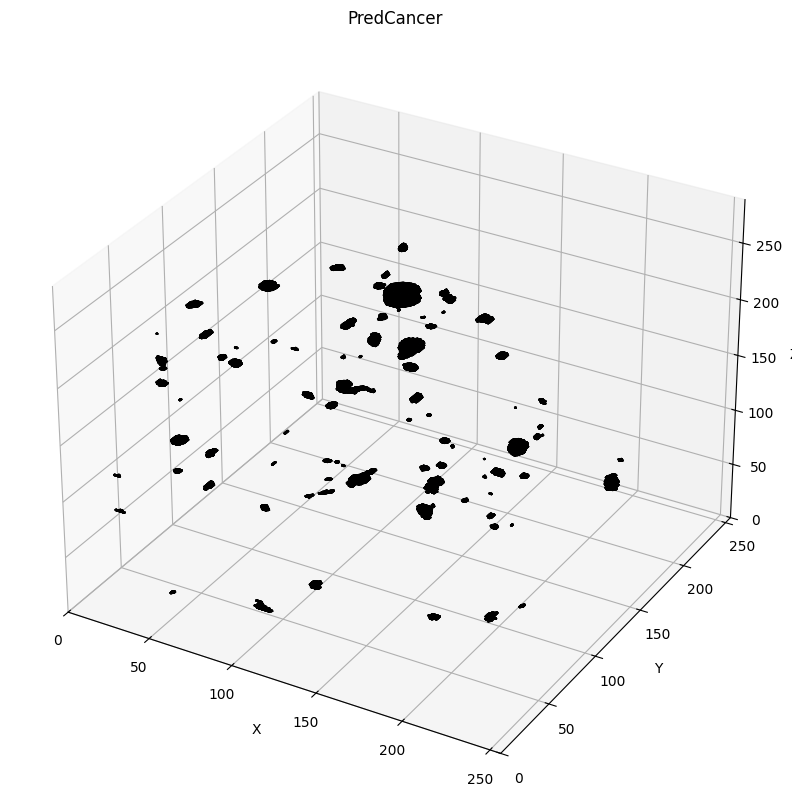

In [ ]:

# Plot the predicted image volume
plot_3d_volume(predImg, "PredCancer")

Image Saved


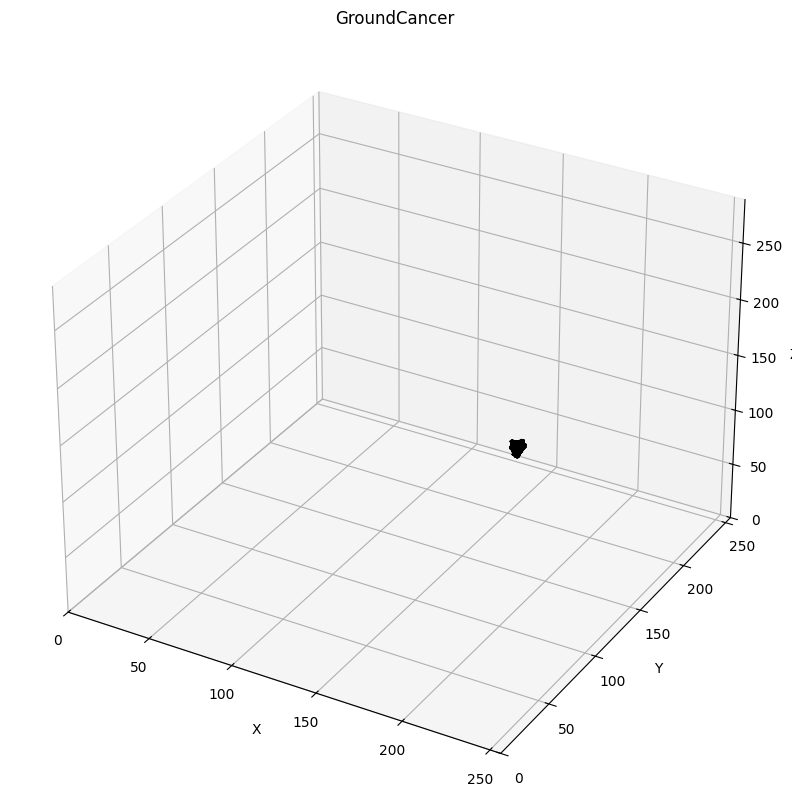

In [ ]:

# Plot the ground truth mask volume
plot_3d_volume(imgMask, "GroundCancer")


In [ ]:
# import os
# import numpy as np
# import nibabel as nib
# import matplotlib.pyplot as plt
# from skimage import measure
# from mpl_toolkits.mplot3d.art3d import Poly3DCollection

# def extract_mesh(volume, threshold=0.5):
#     """Extracts a mesh using marching cubes from a binary volume."""
#     binary = (volume > threshold).astype(np.uint8)
#     verts, faces, _, _ = measure.marching_cubes(binary, level=0)
#     return verts, faces

# def plot_fp_fn(gt_nii_path, pred_nii_path):
#     # Load volumes
#     gt_vol = gt_nii_path
#     pred_vol = pred_nii_path

#     # Binarize
#     gt_bin = (gt_vol > 0.5).astype(np.uint8)
#     pred_bin = (pred_vol > 0.5).astype(np.uint8)

#     # False Positives: pred=1, gt=0
#     false_positives = np.logical_and(pred_bin == 1, gt_bin == 0).astype(np.uint8)
#     fp_verts, fp_faces = extract_mesh(false_positives)

#     # False Negatives: pred=0, gt=1
#     false_negatives = np.logical_and(pred_bin == 0, gt_bin == 1).astype(np.uint8)
#     fn_verts, fn_faces = extract_mesh(false_negatives)

#     # Create subplots
#     fig = plt.figure(figsize=(16, 8))

#     # Plot False Positives
#     ax1 = fig.add_subplot(1, 2, 1, projection='3d')
#     if len(fp_verts) > 0:
#         fp_mesh = Poly3DCollection(fp_verts[fp_faces], alpha=0.6)
#         fp_mesh.set_facecolor('red')
#         ax1.add_collection3d(fp_mesh)
#         ax1.set_title('False Positives (Predicted Extra)')
#     else:
#         ax1.set_title('No False Positives')

#     # Plot False Negatives
#     ax2 = fig.add_subplot(1, 2, 2, projection='3d')
#     if len(fn_verts) > 0:
#         fn_mesh = Poly3DCollection(fn_verts[fn_faces], alpha=0.6)
#         fn_mesh.set_facecolor('blue')
#         ax2.add_collection3d(fn_mesh)
#         ax2.set_title('False Negatives (Missed Predictions)')
#     else:
#         ax2.set_title('No False Negatives')

#     # Set common axis limits
#     all_verts = np.vstack([fp_verts, fn_verts]) if len(fp_verts) > 0 and len(fn_verts) > 0 else (fp_verts if len(fp_verts) > 0 else fn_verts)
#     if all_verts.size > 0:
#         ax1.set_xlim(0, np.max(all_verts[:, 0]))
#         ax1.set_ylim(0, np.max(all_verts[:, 1]))
#         ax1.set_zlim(0, np.max(all_verts[:, 2]))
#         ax2.set_xlim(0, np.max(all_verts[:, 0]))
#         ax2.set_ylim(0, np.max(all_verts[:, 1]))
#         ax2.set_zlim(0, np.max(all_verts[:, 2]))

#     plt.tight_layout()
#     plt.savefig("False_Positive_vs_Negative.png")
#     plt.show()

# # Usage:
# plot_fp_fn(imgMask, predImg)


In [ ]:

# import os
# import torch
# import numpy as np
# import nibabel as nib
# import cv2
# from tqdm import tqdm
# from torch.nn.functional import softmax

# def preprocess_slice(slice_2d):
#     resized = cv2.resize(slice_2d, (256, 256), interpolation=cv2.INTER_AREA)
#     normalized = resized.astype(np.float32) / 255.0
#     tensor = torch.FloatTensor(normalized).unsqueeze(0).unsqueeze(0)  # [1, 1, H, W]
#     return tensor  # [1, 1, 256, 256]


# import nibabel as nib
# import numpy as np
# from skimage import measure
# import matplotlib.pyplot as plt
# from mpl_toolkits.mplot3d.art3d import Poly3DCollection

# def extract_mesh_from_nii(nii_file, threshold=0.5):
#     nii = nib.load(nii_file)
#     volume = nii.get_fdata()
#     binary = (volume > threshold).astype(np.uint8)
#     verts, faces, _, _ = measure.marching_cubes(binary, level=0)
#     return verts, faces

# def plot_two_meshes(gt_nii_path, pred_nii_path):
#     gt_verts, gt_faces = extract_mesh_from_nii(gt_nii_path)
#     pred_verts, pred_faces = extract_mesh_from_nii(pred_nii_path)

#     fig = plt.figure(figsize=(10, 10))
#     ax = fig.add_subplot(111, projection='3d')

#     # Ground Truth Mesh - Blue
#     gt_mesh = Poly3DCollection(gt_verts[gt_faces], alpha=0.4)
#     gt_mesh.set_facecolor('blue')
#     ax.add_collection3d(gt_mesh)

#     # Predicted Mask Mesh - Red
#     pred_mesh = Poly3DCollection(pred_verts[pred_faces], alpha=0.4)
#     pred_mesh.set_facecolor('red')
#     ax.add_collection3d(pred_mesh)

#     # Set axis limits based on larger volume
#     all_verts = np.vstack((gt_verts, pred_verts))
#     ax.set_xlim(0, np.max(all_verts[:, 0]))
#     ax.set_ylim(0, np.max(all_verts[:, 1]))
#     ax.set_zlim(0, np.max(all_verts[:, 2]))

#     ax.set_title("Ground Truth (Blue) vs Predicted Mask (Red)")
#     plt.tight_layout()
#     plt.savefig('PredvsMask.png')
#     plt.show()


In [ ]:
# plot_two_meshes('/root/.cache/kagglehub/datasets/andrewmvd/covid19-ct-scans/versions/4/infection_mask/coronacases_010.nii', "/content/pred_Mask.nii")

NameError: name 'plot_two_meshes' is not defined

In [ ]:
with open('Inferenced_lung_010_pcd.xyz', 'w') as f:
    for line in xyz_load:
        f.write("{}\t {}\t {}\t".format(str(line[0]),str(line[1]),str(line[2])))
        f.write('\n')

One-time pcd loop generation

In [ ]:
for filename in sorted(glob.iglob("./" + '*.stl')):
    mesh = o3d.io.read_triangle_mesh(filename)
    print("Mesh read complete")
    pointcloud = mesh.sample_points_poisson_disk(100000)
    print("PCD generation complete")
    xyz_load = np.asarray(pointcloud.points,dtype=np.float32)
    print('xyz_load shape', xyz_load.shape)
    with open('{}_pcd.xyz'.format(filename[:-4]), 'w') as f:
        for line in xyz_load:
            f.write("{}\t {}\t {}\t".format(str(line[0]),str(line[1]),str(line[2])))
            f.write('\n')

Mesh read complete
PCD generation complete
xyz_load shape (100000, 3)
Mesh read complete
PCD generation complete
xyz_load shape (100000, 3)


##**3D Voxel Morphological stuff**##

In [ ]:
!pip install trimesh -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 712.0/712.0 kB 37.5 MB/s eta 0:00:00


In [ ]:
import numpy as np
import trimesh
from skimage import morphology
from scipy import ndimage
from sklearn.preprocessing import MinMaxScaler
import os
from datetime import datetime

In [ ]:
class Lung3DMorphology:
    def __init__(self, voxel_size=1.0):
        """
        Initialize the 3D morphological operations class.

        Args:
            voxel_size (float): Size of each voxel in the grid (default: 1.0)
        """
        self.voxel_size = voxel_size
        self.mesh = None
        self.voxels = None

    def load_stl(self, file_path):
        """
        Load an STL file containing 3D lung data.

        Args:
            file_path (str): Path to the STL file

        Returns:
            bool: True if loading successful, False otherwise
        """
        try:
            self.mesh = trimesh.load_mesh(file_path)
            print(f"Successfully loaded STL file: {file_path}")
            return True
        except Exception as e:
            print(f"Error loading STL file: {str(e)}")
            return False

    def load_xyz(self, file_path, delimiter='\t'):
      """
      Load an XYZ file containing 3D point cloud data.

      Args:
          file_path (str): Path to the XYZ file
          delimiter (str): Delimiter used in the XYZ file

      Returns:
          bool: True if loading successful, False otherwise
      """
      try:
          # Load points and ensure there are exactly 3 columns
          points = np.genfromtxt(file_path, delimiter=delimiter, invalid_raise=False)
          if points.ndim != 2 or points.shape[1] != 3:
              raise ValueError("XYZ file must contain exactly 3 columns (x, y, z)")

          # Convert point cloud to mesh using convex hull
          self.mesh = trimesh.Trimesh(vertices=points,
                                      faces=trimesh.convex.convex_hull(points)[1])
          print(f"Successfully loaded XYZ file: {file_path}")
          return True
      except Exception as e:
          print(f"Error loading XYZ file: {str(e)}")
          return False


    def convert_to_voxels(self):
        """
        Convert the loaded mesh to a voxel representation.

        Returns:
            bool: True if conversion successful, False otherwise
        """
        if self.mesh is None:
            print("No mesh loaded. Please load an STL or XYZ file first.")
            return False

        try:
            # Voxelize the mesh
            voxelized = self.mesh.voxelized(pitch=self.voxel_size)
            self.voxels = voxelized.matrix
            print(f"Converted mesh to voxels with shape: {self.voxels.shape}")
            return True
        except Exception as e:
            print(f"Error converting to voxels: {str(e)}")
            return False

    def apply_erosion(self, iterations, structure=None):
      """
      Apply morphological erosion to the voxel representation.

      Args:
          iterations (int): Number of erosion iterations
          structure (ndarray): Structuring element for erosion

      Returns:
          ndarray: Eroded voxel array
      """
      if self.voxels is None:
          print("No voxels available. Please convert mesh to voxels first.")
          return None

      if structure is None:
          structure = morphology.ball(1)

      try:
          eroded = self.voxels.copy()
          for _ in range(iterations):
              eroded = morphology.binary_erosion(eroded, footprint=structure)

          print(f"Applied erosion with {iterations} iterations")
          return eroded
      except Exception as e:
          print(f"Error during erosion: {str(e)}")
          return None

    def apply_dilation(self, iterations, structure=None):
        """
        Apply morphological dilation to the voxel representation.

        Args:
            iterations (int): Number of dilation iterations
            structure (ndarray): Structuring element for dilation

        Returns:
            ndarray: Dilated voxel array
        """
        if self.voxels is None:
            print("No voxels available. Please convert mesh to voxels first.")
            return None

        if structure is None:
            structure = morphology.ball(1)  # Default 3D structuring element

        try:
            dilated = self.voxels.copy()
            for _ in range(iterations):
                dilated = morphology.binary_dilation(dilated, footprint=structure)

            print(f"Applied dilation with {iterations} iterations")
            return dilated
        except Exception as e:
            print(f"Error during dilation: {str(e)}")
            return None


    def voxels_to_mesh(self, voxels):
        """
        Convert voxel representation back to mesh.

        Args:
            voxels (ndarray): Binary voxel array

        Returns:
            trimesh.Trimesh: Resulting mesh
        """
        try:
            from skimage import measure

            # Use marching cubes to convert voxels to mesh
            verts, faces, normals, _ = measure.marching_cubes(voxels)

            # Scale vertices by voxel size
            verts *= self.voxel_size

            # Create mesh
            result_mesh = trimesh.Trimesh(
                vertices=verts,
                faces=faces,
                vertex_normals=normals
            )

            return result_mesh
        except Exception as e:
            print(f"Error converting voxels to mesh: {str(e)}")
            return None

    def save_result(self, mesh, output_path):
        """
        Save the resulting mesh to an STL file.

        Args:
            mesh (trimesh.Trimesh): Mesh to save
            output_path (str): Path to save the STL file

        Returns:
            bool: True if saving successful, False otherwise
        """
        try:
            mesh.export(output_path)
            print(f"Successfully saved result to: {output_path}")
            return True
        except Exception as e:
            print(f"Error saving result: {str(e)}")
            return False

In [ ]:

def main():
    # Example usage
    processor = Lung3DMorphology(voxel_size=1.0)

    # Create timestamp for output files
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

    # Process STL file
    stl_path = "/content/Inferenced_lung_003.stl"  # Replace with your input file path
    if os.path.exists(stl_path):
        processor.load_stl(stl_path)
        processor.convert_to_voxels()

        # # Apply erosion
        # eroded_voxels = processor.apply_erosion(iterations=2)
        # if eroded_voxels is not None:
        #     eroded_mesh = processor.voxels_to_mesh(eroded_voxels)
        #     processor.save_result(eroded_mesh, f"lung_eroded_{timestamp}.stl")

        # Apply dilation
        dilated_voxels = processor.apply_dilation(iterations=2)
        if dilated_voxels is not None:
            dilated_mesh = processor.voxels_to_mesh(dilated_voxels)
            processor.save_result(dilated_mesh, f"lung_dilated_{timestamp}.stl")

    # Process XYZ file
    # xyz_path = "/content/Inferenced_lung_010_pcd.xyz"  # Replace with your input file path
    # if os.path.exists(xyz_path):
    #     processor.load_xyz(xyz_path)
    #     processor.convert_to_voxels()

    #     # Apply erosion
    #     eroded_voxels = processor.apply_erosion(iterations=3)
    #     if eroded_voxels is not None:
    #         eroded_mesh = processor.voxels_to_mesh(eroded_voxels)
    #         processor.save_result(eroded_mesh, f"lung_xyz_eroded_{timestamp}.stl")

    #     # Apply dilation
    #     dilated_voxels = processor.apply_dilation(iterations=3)
    #     if dilated_voxels is not None:
    #         dilated_mesh = processor.voxels_to_mesh(dilated_voxels)
    #         processor.save_result(dilated_mesh, f"lung_xyz_dilated_{timestamp}.stl")

if __name__ == "__main__":
    main()

Successfully loaded STL file: /content/Inferenced_lung_003.stl
Converted mesh to voxels with shape: (229, 229, 288)
Applied dilation with 2 iterations
Successfully saved result to: lung_dilated_20250620_171717.stl


##TRYING RBF NOW##

In [ ]:
!pip install open3d -q
!pip install pymeshfix -q
!pip install scipy -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 68.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 77.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.0/105.0 MB 11.0 MB/s eta 0:00:00


In [ ]:
import os
import open3d as o3d
import numpy as np
from scipy.interpolate import Rbf

In [ ]:
def set_mesh_color(mesh, color):
    if not mesh.has_vertices():
        print("Mesh has no vertices to color.")
        return
    colors = [color for _ in range(len(mesh.vertices))]
    mesh.vertex_colors = o3d.utility.Vector3dVector(colors)

gaussian, multiquadrartic or thin-plate

In [ ]:
def apply_rbf_smoothing(pcd):
    points = np.asarray(pcd.points)

    # Extract x, y, z coordinates
    x, y, z = points[:, 0], points[:, 1], points[:, 2]

    # RBF interpolation for smoothing
    rbf_x = Rbf(x, y, z, function='gaussian', smooth=0.1)
    rbf_y = Rbf(y, z, x, function='gaussian', smooth=0.1)
    rbf_z = Rbf(z, x, y, function='gaussian', smooth=0.1)

    # Generate new points
    smoothed_points = np.column_stack((rbf_x(x, y, z), rbf_y(y, z, x), rbf_z(z, x, y)))

    # Update the point cloud with smoothed points
    pcd.points = o3d.utility.Vector3dVector(smoothed_points)
    return pcd



In [ ]:

def process_point_cloud(ply_file, output_mesh_file, color=(0.1, 0.1, 0.7)):
    print(f"Processing: {ply_file}")
    pcd = o3d.io.read_point_cloud(ply_file)

    # Downsample and remove noise
    pcd = pcd.voxel_down_sample(voxel_size=0.05)
    print("Downsampling complete.")
    pcd, ind = pcd.remove_statistical_outlier(nb_neighbors=10, std_ratio=1.0)
    print("Noise removal complete.")

    # Estimate normals
    pcd.estimate_normals(search_param=o3d.geometry.KDTreeSearchParamHybrid(radius=0.05, max_nn=20))
    print("Normal estimation complete.")

    # Poisson reconstruction
    mesh, densities = o3d.geometry.TriangleMesh.create_from_point_cloud_poisson(pcd, depth=6)
    print("Poisson reconstruction complete.")

    if not mesh.has_vertices():
        print(f"No vertices found in the generated mesh for {ply_file}. Skipping.")
        return

    mesh.compute_vertex_normals()
    set_mesh_color(mesh, color)

    o3d.io.write_triangle_mesh(output_mesh_file, mesh, write_vertex_normals=True, write_vertex_colors=True)
    print(f"Processed and saved: {output_mesh_file}")

In [ ]:
def visualize_mesh(mesh_file):
    mesh = o3d.io.read_triangle_mesh(mesh_file)
    mesh.compute_vertex_normals()

    if not mesh.has_vertex_colors():
        print(f"Mesh {mesh_file} has no vertex colors. Visualizing without colors.")

    o3d.visualization.draw_geometries([mesh], mesh_show_back_face=True)

In [ ]:
def compute_properties(mesh_file):
    mesh = o3d.io.read_triangle_mesh(mesh_file)
    mesh.compute_vertex_normals()
    return mesh.get_surface_area()

In [ ]:

input_xyz_file = "/content/Inferenced_lung_010_pcd.xyz"
output_dir = "/content/results"

# Ensure output directory exists
os.makedirs(output_dir, exist_ok=True)

# Define the output mesh file path
output_mesh_file = os.path.join(output_dir, "Inferenced_lung_010_mesh.obj")

# Process the point cloud
process_point_cloud(input_xyz_file, output_mesh_file, color=(0.4, 0.4, 0.4))

# Compute and save mesh properties
surface_area = compute_properties(output_mesh_file)

# Log the results
log_file_path = os.path.join(output_dir, "results_log.txt")
with open(log_file_path, "w") as log_file:
    log_file.write(f"Processed Mesh: {output_mesh_file}\n")
    log_file.write(f"Surface Area: {surface_area}\n")

print(f"Results logged in: {log_file_path}")

# Visualize the mesh
visualize_mesh(output_mesh_file)

Processing: /content/Inferenced_lung_010_pcd.xyz
Downsampling complete.
Noise removal complete.
Normal estimation complete.
Poisson reconstruction complete.
[Open3D WARNING] Write OBJ can not include triangle normals.
Processed and saved: /content/results/Inferenced_lung_010_mesh.obj
Results logged in: /content/results/results_log.txt
[Open3D WARNING] GLFW Error: Failed to detect any supported platform
[Open3D WARNING] GLFW initialized for headless rendering.
[Open3D WARNING] GLFW Error: OSMesa: Library not found
[Open3D WARNING] Failed to create window
[Open3D WARNING] [DrawGeometries] Failed creating OpenGL window.


uses RBF+Ball-pivot

In [ ]:
import os
import open3d as o3d
import numpy as np
from scipy.interpolate import RBFInterpolator

def remove_background(mesh, min_component_size=1000):
    """ Remove unwanted background surfaces based on connected components. """
    if not mesh.has_vertices():
        print("Warning: Mesh has no vertices!")
        return mesh


    triangle_clusters, cluster_n_triangles, _ = mesh.cluster_connected_triangles()
    cluster_n_triangles = np.array(cluster_n_triangles)


    largest_cluster_idx = np.argmax(cluster_n_triangles)


    filtered_triangles = [i for i, c in enumerate(triangle_clusters) if c == largest_cluster_idx]

    if len(filtered_triangles) < min_component_size:
        print("Warning: The detected component is too small, check the input!")
        return mesh

    mesh_filtered = mesh.select_by_index(filtered_triangles, invert=False)

    return mesh_filtered


def set_mesh_color(mesh, color):
    """ Set uniform color for the mesh. """
    if not mesh.has_vertices():
        print("Mesh has no vertices to color.")
        return
    colors = np.tile(color, (len(mesh.vertices), 1))
    mesh.vertex_colors = o3d.utility.Vector3dVector(colors)

def apply_rbf_surface_fitting(pcd):
    """ Fit an implicit RBF surface to smooth and reconstruct the lung shape. """
    points = np.asarray(pcd.points)


    num_samples = min(len(points), 5000)
    sampled_indices = np.random.choice(len(points), num_samples, replace=False)
    sampled_points = points[sampled_indices]


    rbf = RBFInterpolator(sampled_points, np.zeros(len(sampled_points)), kernel='thin_plate_spline')
    smoothed_points = points + 0.01 * np.expand_dims(rbf(points), axis=1)

    pcd.points = o3d.utility.Vector3dVector(smoothed_points)
    return pcd

def process_point_cloud(input_file, output_mesh_file, color=(0.4, 0.4, 0.4), use_bpa=True):
    print(f"Processing: {input_file}")
    pcd = o3d.io.read_point_cloud(input_file)

    # Reduce point cloud density
    pcd = pcd.voxel_down_sample(voxel_size=0.1)
    print("Downsampling complete.")

    # Remove noise
    pcd, ind = pcd.remove_statistical_outlier(nb_neighbors=10, std_ratio=1.0)
    print("Noise removal complete.")

    # Estimate normals
    pcd.estimate_normals(search_param=o3d.geometry.KDTreeSearchParamHybrid(radius=0.1, max_nn=30))
    print("Normal estimation complete.")

    pcd = apply_rbf_surface_fitting(pcd)
    print("RBF smoothing applied.")

    if use_bpa:
        # Ball Pivoting Algorithm (BPA) for meshing
        distances = pcd.compute_nearest_neighbor_distance()
        avg_dist = np.mean(distances)
        mesh = o3d.geometry.TriangleMesh.create_from_point_cloud_ball_pivoting(
            pcd, o3d.utility.DoubleVector([avg_dist * 1.5, avg_dist * 3.0])
        )
        print("Ball Pivoting reconstruction complete.")
    else:
        # Poisson Reconstruction (only if BPA fails)
        mesh, densities = o3d.geometry.TriangleMesh.create_from_point_cloud_poisson(pcd, depth=5)
        mesh = remove_background(mesh, density_threshold=0.1)
        print("Poisson reconstruction complete with background removal.")

    if not mesh.has_vertices():
        print(f"No vertices found in the generated mesh for {input_file}. Skipping.")
        return

    mesh.compute_vertex_normals()
    set_mesh_color(mesh, color)

    o3d.io.write_triangle_mesh(output_mesh_file, mesh, write_vertex_normals=True, write_vertex_colors=True)
    print(f"Processed and saved: {output_mesh_file}")

def visualize_mesh(mesh_file):
    """ Load and visualize the mesh. """
    mesh = o3d.io.read_triangle_mesh(mesh_file)
    mesh.compute_vertex_normals()

    if not mesh.has_vertex_colors():
        print(f"Mesh {mesh_file} has no vertex colors. Visualizing without colors.")

    o3d.visualization.draw_geometries([mesh], mesh_show_back_face=True)

def compute_properties(mesh_file):
    """ Compute surface area of the mesh. """
    mesh = o3d.io.read_triangle_mesh(mesh_file)
    mesh.compute_vertex_normals()
    return mesh.get_surface_area()

input_xyz_file = "/content/Inferenced_lung_010_pcd.xyz"
output_dir = "/content/results"
os.makedirs(output_dir, exist_ok=True)
output_mesh_file = os.path.join(output_dir, "Inferenced_lung_003_mesh.obj")


process_point_cloud(input_xyz_file, output_mesh_file, color=(0.4, 0.4, 0.4), use_bpa=True)

surface_area = compute_properties(output_mesh_file)
log_file_path = os.path.join(output_dir, "results_log.txt")
with open(log_file_path, "w") as log_file:
    log_file.write(f"Processed Mesh: {output_mesh_file}\n")
    log_file.write(f"Surface Area: {surface_area}\n")

print(f"Results logged in: {log_file_path}")

visualize_mesh(output_mesh_file)


Processing: /content/Inferenced_lung_010_pcd.xyz
Downsampling complete.
Noise removal complete.
Normal estimation complete.
RBF smoothing applied.
Ball Pivoting reconstruction complete.
[Open3D WARNING] Write OBJ can not include triangle normals.
Processed and saved: /content/results/Inferenced_lung_003_mesh.obj
Results logged in: /content/results/results_log.txt
[Open3D WARNING] GLFW initialized for headless rendering.
[Open3D WARNING] GLFW Error: OSMesa: Library not found
[Open3D WARNING] Failed to create window
[Open3D WARNING] [DrawGeometries] Failed creating OpenGL window.


In [ ]:
import os
import open3d as o3d
import numpy as np
from scipy.interpolate import Rbf

def extract_boundary_points(mesh):
    edges = mesh.get_non_manifold_edges(allow_boundary_edges=True)
    if edges is None or len(edges) == 0:
        print("No boundary edges found.")
        return None
    boundary_indices = np.unique(np.concatenate(edges))
    boundary_vertices = np.asarray(mesh.vertices)[boundary_indices]
    if len(boundary_vertices) < 5:
        print("Too few boundary points for RBF interpolation.")
        return None
    return boundary_vertices

def fill_holes_rbf(mesh, num_samples=20000, iterations=3):
    for i in range(iterations):
        boundary_points = extract_boundary_points(mesh)
        if boundary_points is None:
            break
        x, y, z = boundary_points[:, 0], boundary_points[:, 1], boundary_points[:, 2]
        indices = np.random.choice(len(x), min(num_samples, len(x)), replace=False)
        sx, sy, sz = x[indices], y[indices], z[indices]
        rbf = Rbf(sx, sy, sz, function='multiquadric', smooth=0.01)
        grid_x, grid_y = np.meshgrid(np.linspace(min(sx), max(sx), 300), np.linspace(min(sy), max(sy), 300))
        grid_z = rbf(grid_x, grid_y)
        new_points = np.vstack((grid_x.flatten(), grid_y.flatten(), grid_z.flatten())).T
        new_pcd = o3d.geometry.PointCloud()
        new_pcd.points = o3d.utility.Vector3dVector(new_points)
        poisson_mesh = o3d.geometry.TriangleMesh.create_from_point_cloud_poisson(new_pcd, depth=12)[0]
        poisson_mesh = poisson_mesh.filter_smooth_taubin(number_of_iterations=20)
        poisson_mesh.compute_vertex_normals()
        mesh += poisson_mesh
    return mesh

def process_point_cloud(input_file, output_mesh_file):
    print(f"Processing: {input_file}")
    pcd = o3d.io.read_point_cloud(input_file)
    pcd = pcd.voxel_down_sample(voxel_size=0.15)
    pcd.estimate_normals(search_param=o3d.geometry.KDTreeSearchParamHybrid(radius=1.0, max_nn=150))
    bpa_mesh = o3d.geometry.TriangleMesh.create_from_point_cloud_ball_pivoting(
        pcd, o3d.utility.DoubleVector([0.5, 0.9, 1.3]))
    bpa_mesh = bpa_mesh.filter_smooth_taubin(number_of_iterations=10)
    bpa_mesh.compute_vertex_normals()
    mesh = fill_holes_rbf(bpa_mesh, num_samples=20000, iterations=3)
    o3d.io.write_triangle_mesh(output_mesh_file, mesh)
    print(f"Processed and saved: {output_mesh_file}")

input_xyz_file = "/content/Inferenced_lung_010_pcd.xyz"
output_dir = "/content/results"
os.makedirs(output_dir, exist_ok=True)
output_mesh_file = os.path.join(output_dir, "lung_010_mesh.obj")
process_point_cloud(input_xyz_file, output_mesh_file)







# import os
# import open3d as o3d
# import numpy as np
# from scipy.interpolate import Rbf

# def extract_boundary_points(mesh):
#     edges = mesh.get_non_manifold_edges(allow_boundary_edges=True)
#     if edges is None or len(edges) == 0:
#         print("No boundary edges found.")
#         return None

#     boundary_indices = np.unique(np.concatenate(edges))
#     boundary_vertices = np.asarray(mesh.vertices)[boundary_indices]

#     if len(boundary_vertices) < 5:
#         print("Too few boundary points for RBF interpolation.")
#         return None

#     return boundary_vertices

# def fill_holes_rbf(mesh, num_samples=5000):
#     boundary_points = extract_boundary_points(mesh)
#     if boundary_points is None:
#         return mesh

#     x, y, z = boundary_points[:, 0], boundary_points[:, 1], boundary_points[:, 2]

#     indices = np.random.choice(len(x), min(num_samples, len(x)), replace=False)
#     sx, sy, sz = x[indices], y[indices], z[indices]

#     rbf = Rbf(sx, sy, sz, function='multiquadric', smooth=0.1)
#     grid_x, grid_y = np.meshgrid(np.linspace(min(sx), max(sx), 100), np.linspace(min(sy), max(sy), 100))
#     grid_z = rbf(grid_x, grid_y)

#     new_points = np.vstack((grid_x.flatten(), grid_y.flatten(), grid_z.flatten())).T
#     new_pcd = o3d.geometry.PointCloud()
#     new_pcd.points = o3d.utility.Vector3dVector(new_points)

#     poisson_mesh = o3d.geometry.TriangleMesh.create_from_point_cloud_poisson(new_pcd, depth=8)[0]
#     poisson_mesh.compute_vertex_normals()
#     return poisson_mesh

# def process_point_cloud(input_file, output_mesh_file):
#     print(f"Processing: {input_file}")
#     pcd = o3d.io.read_point_cloud(input_file)

#     pcd = pcd.voxel_down_sample(voxel_size=0.3)
#     pcd.estimate_normals(search_param=o3d.geometry.KDTreeSearchParamHybrid(radius=1.0, max_nn=50))

#     bpa_mesh = o3d.geometry.TriangleMesh.create_from_point_cloud_ball_pivoting(
#         pcd, o3d.utility.DoubleVector([0.8, 1.2, 1.6]))

#     bpa_mesh.compute_vertex_normals()
#     mesh = fill_holes_rbf(bpa_mesh)

#     o3d.io.write_triangle_mesh(output_mesh_file, mesh)
#     print(f"Processed and saved: {output_mesh_file}")

# input_xyz_file = "/content/Inferenced_lung_010_pcd.xyz"
# output_dir = "/content/results"
# os.makedirs(output_dir, exist_ok=True)
# output_mesh_file = os.path.join(output_dir, "Inferenced_lung_010_mesh.obj")
# process_point_cloud(input_xyz_file, output_mesh_file)


Processing: /content/Inferenced_lung_010_pcd.xyz
No boundary edges found.
[Open3D WARNING] Write OBJ can not include triangle normals.
Processed and saved: /content/results/lung_010_mesh.obj


##**RANDOM ATTEMPT AT COLOURING**##

CT Scan Statistics:
  Shape: (512, 512, 301)
  Min HU: -1021.0
  Max HU: 2996.0
  Mean HU: -588.7147150388191
  Std Dev: 482.1985038715103


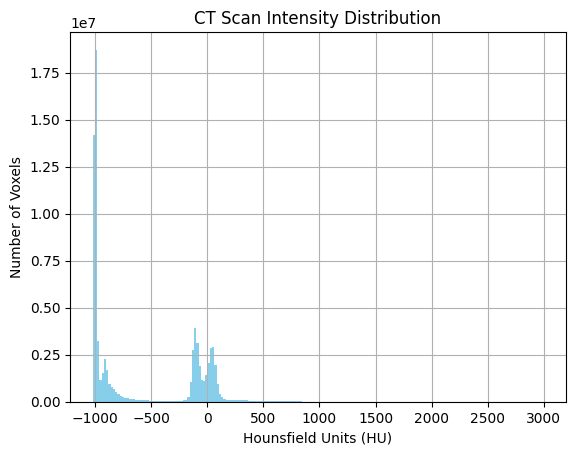

In [ ]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt


ct_path = '/root/.cache/kagglehub/datasets/andrewmvd/covid19-ct-scans/versions/4/ct_scans/coronacases_org_001.nii'
ct_img = nib.load(ct_path)
ct_data = ct_img.get_fdata()


print(f"CT Scan Statistics:")
print(f"  Shape: {ct_data.shape}")
print(f"  Min HU: {np.min(ct_data)}")
print(f"  Max HU: {np.max(ct_data)}")
print(f"  Mean HU: {np.mean(ct_data)}")
print(f"  Std Dev: {np.std(ct_data)}")


plt.hist(ct_data.flatten(), bins=200, color='skyblue')
plt.title('CT Scan Intensity Distribution')
plt.xlabel('Hounsfield Units (HU)')
plt.ylabel('Number of Voxels')
plt.grid(True)
plt.show()


In [ ]:
unique_vals = np.unique(mask_data)
print("Unique values in lung_and_infection_mask:", unique_vals)


In [ ]:
# Pick a random vertex index that is valid
valid_indices = np.where(valid_mask)[0]
rand_idx = np.random.choice(valid_indices)

vx, vy, vz = voxel_coords[rand_idx]
print("Random Vertex:", vertices[rand_idx])
print("Mapped to Voxel:", vx, vy, vz)
print("Mask Value:", mask_data[vx, vy, vz])
print("HU Value:", ct_data[vx, vy, vz])


In [ ]:
import numpy as np
import nibabel as nib
import open3d as o3d

ct = nib.load('/kaggle/input/covid19-ct-scans/ct_scans/coronacases_org_001.nii').get_fdata()
mask = nib.load('/kaggle/input/covid19-ct-scans/infection_mask/coronacases_001.nii').get_fdata()
lung_mask = mask > 0


In [ ]:
import open3d as o3d


In [ ]:
import numpy as np
import nibabel as nib
import open3d as o3d
import os # Import the os module

# ct = nib.load('/root/.cache/kagglehub/datasets/andrewmvd/covid19-ct-scans/versions/4/ct_scans/coronacases_org_001.nii').get_fdata()
# mask = nib.load('/root/.cache/kagglehub/datasets/andrewmvd/covid19-ct-scans/versions/4/infection_mask/coronacases_001.nii').get_fdata()
# lung_mask = mask > 0


lung_indices = np.argwhere(lung_mask)
zmin, ymin, xmin = lung_indices.min(axis=0)
zmax, ymax, xmax = lung_indices.max(axis=0)

print(f"Lung bbox: Z({zmin}-{zmax}), Y({ymin}-{ymax}), X({xmin}-{xmax})")

lung_bbox_min = np.array([xmin, ymin, zmin])
lung_bbox_max = np.array([xmax, ymax, zmax])

stl_file_path = '/content/Mask_lung_010.stl'

# Check if the file exists before attempting to load
if not os.path.exists(stl_file_path):
    print(f"Error: STL file not found at {stl_file_path}")
else:
    mesh = o3d.io.read_triangle_mesh(stl_file_path)
    vertices = np.asarray(mesh.vertices)

    if vertices.shape[0] == 0:
        print(f"Error: No vertices loaded from {stl_file_path}")
    else:
        vmin = vertices.min(axis=0)
        vmax = vertices.max(axis=0)
        vertices_normalized = (vertices - vmin) / (vmax - vmin)


        lung_bbox_size = lung_bbox_max - lung_bbox_min
        vertices_voxel = vertices_normalized * lung_bbox_size[::-1] + lung_bbox_min[::-1]
        ct_shape = ct.shape
        vertices_voxel = np.clip(vertices_voxel, 0, np.array(ct_shape[::-1]) - 1).astype(int)


        colors = []

        for idx in range(vertices_voxel.shape[0]):
            z, y, x = vertices_voxel[idx]

            if not (0 <= z < ct_shape[0] and 0 <= y < ct_shape[1] and 0 <= x < ct_shape[2]):
                colors.append([0.5, 0.5, 0.5])
                continue

            if lung_mask[z, y, x] == 0:
                colors.append([0.5, 0.5, 0.5])
                continue

            hu = ct[z, y, x]

            # New thresholds
            if hu < -800:
                colors.append([0, 1, 0])  # Green (healthy)
            elif -800 <= hu <= -400:
                colors.append([1, 1, 0])  # Yellow (moderate infection)
            else:
                colors.append([1, 0, 0])  # Red (severe infection)


        colors = np.array(colors)
        mesh.vertex_colors = o3d.utility.Vector3dVector(colors)


        o3d.io.write_triangle_mesh('/content/colored_lung_True_attempt.obj', mesh)

        print("Done making the mesh")

Lung bbox: Z(97-405), Y(217-436), X(78-243)
Done making the mesh


In [ ]:
# Save mesh as .ply (which supports vertex colors better for web)
mesh = o3d.io.read_triangle_mesh('/content/Inferenced_lung_003.stl')
o3d.io.write_triangle_mesh("colored_lung_attempt.ply", mesh)

# Load with Plotly (approximate)
import open3d as o3d
import numpy as np
from matplotlib import pyplot as plt
import plotly.graph_objects as go

mesh = o3d.io.read_triangle_mesh("colored_lung_attempt.ply")
vertices = np.asarray(mesh.vertices)
triangles = np.asarray(mesh.triangles)
colors = np.asarray(mesh.vertex_colors)

fig = go.Figure(
    data=[
        go.Mesh3d(
            x=vertices[:, 0],
            y=vertices[:, 1],
            z=vertices[:, 2],
            i=triangles[:, 0],
            j=triangles[:, 1],
            k=triangles[:, 2],
            vertexcolor=colors,
            opacity=1.0
        )
    ]
)
fig.update_layout(scene=dict(aspectmode="data"))
fig.show()
